<a href="https://colab.research.google.com/github/Wilson1994/DTA-2026/blob/main/homework/practice_stat_tests_HARDER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

users = pd.read_csv("saas_users.csv")
ab = pd.read_csv("onboarding_ab.csv")

print("Користувачі:", users.shape)
print("A/B онбординг:", ab.shape)
users.head()

Користувачі: (1200, 9)
A/B онбординг: (100000, 3)


,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [3]:
# Завдання 1:

users.describe()


,user_id,support_tickets,weekly_sessions,nps_before,nps_after
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,10600.500000,2.105000,11.500833,6.930000,7.149167
std,346.554469,2.606333,6.395109,1.916114,2.200216
min,10001.000000,0.000000,1.000000,1.000000,0.000000
25%,10300.750000,0.000000,7.000000,6.000000,6.000000
50%,10600.500000,1.000000,11.000000,7.000000,7.000000
75%,10900.250000,3.000000,16.000000,8.000000,9.000000
max,11200.000000,20.000000,38.000000,10.000000,10.000000


In [4]:
mean_tickets = users['support_tickets'].mean()
median_tickets = users['support_tickets'].median()

print("Середнє:", mean_tickets)
print("Медіана:", median_tickets)
print("Різниця:", mean_tickets - median_tickets)

Середнє: 2.105
Медіана: 1.0
Різниця: 1.105


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Среднее (2.105) заметно выше медианы (1.0), значит распределение support_tickets скошено вправо.

Это говорит о том, что большинство пользователей почти не обращаются в поддержку (0–1 тикет), но есть небольшая группа пользователей с очень большим количеством обращений, которые сильно поднимают среднее.

Из-за таких выбросов среднее плохо отражает “типичного” пользователя, поэтому с этим показателем нужно быть осторожным.

t-тест в такой ситуации тоже может давать искажённые результаты, потому что он чувствителен к выбросам и опирается на средние значения.

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

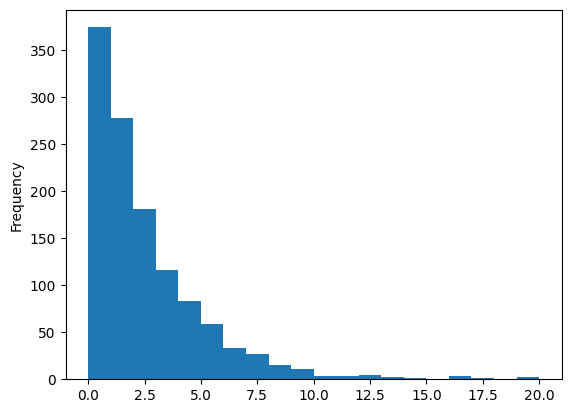

In [5]:
# Завдання 2:

import matplotlib.pyplot as plt

users['support_tickets'].plot(kind='hist', bins=20)
plt.show()


#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

На гистограмме видно, что большинство значений support_tickets сосредоточено в области маленьких значений (примерно 0–2). Дальше частота резко падает, но есть длинный хвост вправо — до больших значений.

Это означает, что распределение скошено вправо: основная масса пользователей почти не обращается в поддержку, а небольшая группа пользователей создаёт много тикетов.

Да, гистограмма подтверждает вывод из предыдущего задания — в данных есть сильная асимметрия и выбросы (редкие, но очень большие значения).

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [6]:
# Завдання 3:

users.groupby('plan')['weekly_sessions'].mean()


,weekly_sessions
plan,
Business,19.585799
Free,7.931667
Pro,13.299304


In [7]:
from scipy import stats

groups = [users[users.plan == p]['weekly_sessions'] for p in users['plan'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-статистика:", f_stat)
print("p-value:", p_value)

F-статистика: 415.1935969398753
p-value: 1.090773844553071e-137


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Да, тарифы отличаются по активности пользователей. Самый активный — Business, затем Pro, меньше всего активны пользователи Free.

Но ANOVA не показывает, между какими именно группами есть различия — он говорит только, что разница есть хотя бы где-то.

Поэтому нельзя утверждать, что Pro значимо активнее Free. Для этого нужны пост-хок тесты (например, Tukey) или попарные сравнения с поправкой на множественные проверки.

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [9]:
# Завдання 4:

users.groupby('region')['weekly_sessions'].mean()

,weekly_sessions
region,
Americas,10.783529
Asia,11.523929
Europe,12.283069


In [11]:
groups = [users[users.region == r]['weekly_sessions'] for r in users['region'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-статистика:", f_stat)
print("p-value:", p_value)

F-статистика: 5.545503308553481
p-value: 0.0040059700759991265


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Если сравнить с тарифами, то видно, что тариф влияет на активность сильнее, чем регион.

По тарифам разница между группами заметная (Free - Pro - Business), а по регионам средние очень близкие и различия слабее.

То есть именно тип подписки больше связан с weekly_sessions, чем география пользователя.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [12]:
# Завдання 5:

t_stat, p_value = stats.ttest_rel(users['nps_after'], users['nps_before'])

print("t-статистика:", t_stat)
print("p-value:", p_value)


t-статистика: 5.49917430193314
p-value: 4.659740480089134e-08


In [13]:
mean_change = (users['nps_after'] - users['nps_before']).mean()
print("Среднее изменение NPS:", mean_change)

Среднее изменение NPS: 0.21916666666666668


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Да, изменение NPS после нового онбординга статистически значимое — p-value очень маленькое, поэтому можно уверенно сказать, что эффект не случайный.

Но если посмотреть на размер эффекта, то средний рост составляет всего около +0.22 балла из 10. Это очень небольшое изменение.

Получается классическая ситуация:
статистически значимо — да, эффект есть
практически значимо — скорее нет или очень слабо

То есть новый онбординг действительно улучшил NPS, но настолько слабо, что с бизнес-точки зрения это вряд ли повод для победных отчётов.

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [14]:
# Завдання 6:

ab.groupby('variant')['signed_up'].mean()


,signed_up
variant,
Control,0.19876
Treatment,0.20764


In [15]:
conv = ab.groupby('variant')['signed_up'].mean()

diff_pp = (conv['Treatment'] - conv['Control']) * 100
print("Разница (п.п.):", diff_pp)

Разница (п.п.): 0.8879999999999999


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Разница конверсий между вариантами составляет примерно 0.89 процентного пункта: в Control ~19.88%, в Treatment ~20.76%.

На первый взгляд это довольно небольшое изменение — меньше одного процентного пункта.

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [16]:
# Завдання 7:

table = pd.crosstab(ab['variant'], ab['signed_up'])
print(table)


signed_up      0      1
variant                
Control    40062   9938
Treatment  39618  10382


In [17]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)

chi2: 12.120887585776176
p-value: 0.0004986016595676651


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Разница в конверсии меньше 1 процентного пункта, но тест показывает статистическую значимость, потому что у нас очень большая выборка — 100 000 пользователей. При таком объёме даже очень маленькие отклонения от нуля становятся заметными для статистических тестов.

Смысл в том, что p-value отвечает на вопрос: может ли эта разница быть случайностью?, а не насколько она важна. Когда данных много, случайный шум сильно уменьшается, и тест начинает видеть даже крошечные эффекты как уверенные.

Поэтому получается парадокс: эффект маленький, но уверенно отличимый от нуля. Это значит, что он реален, но не обязательно бизнес-значим.

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

З точки зрения статистики, новый онбординг действительно работает - разница значимая, и эффект не случайный. Но если смотреть на бизнес-сторону, прирост всего около +0.9 процентного пункта — это очень небольшой эффект.

Если внедрение требует больших затрат (переписывание кода, время команды, поддержка), то такой выигрыш выглядит сомнительно. В масштабах бизнеса он может дать рост, но не настолько большой, чтобы однозначно оправдать дорогую реализацию.

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [18]:
# Завдання 8:

table = pd.crosstab(users['plan'], users['feature_adopted'])
print(table)


feature_adopted   Ні  Так
plan                     
Business          54  115
Free             453  147
Pro              204  227


In [19]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)

chi2: 143.13388695042337
p-value: 8.29605002229765e-32


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Интерпретация
Чётко видно, что:
Business-пользователи чаще всего принимают новую функцию (68%)
затем идёт Pro (53%)
и заметно реже всего - Free (25%)

Что это значит для продукта

Есть явная зависимость: чем выше тариф, тем выше вероятность, что пользователь попробует новую функцию.

Это может означать:
платные пользователи более вовлечены
или функция лучше подходит для продвинутых сценариев
или Free-уровень недостаточно мотивирован/ограничен



#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [20]:
# Завдання 9:

table = pd.crosstab(users['signup_source'], users['feature_adopted'])
print(table)


feature_adopted   Ні  Так
signup_source            
Ads              208  128
Referral         177  100
Search           227  186
Social            99   75


In [21]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)

chi2: 7.002162949801651
p-value: 0.071828863875168


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Тут ситуация на грани. p-value = 0.072 — это чуть выше 0.05, то есть по стандартному правилу мы не можем считать результат значимым.

Говорить почти значимо — не очень правильно, потому что это создаёт ощущение, будто связь есть, просто чуть-чуть не хватило. На самом деле это просто означает: доказательств пока недостаточно.

Возможно, связь между источником регистрации и использованием функции и правда слабая, но данных либо мало, либо эффект неустойчивый.

Я бы не делал сильных выводов здесь. Лучше либо собрать больше данных, либо перепроверить результат на других сегментах.

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [22]:
# Завдання 10:

r, p = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])

print("r:", r)
print("p-value:", p)

r: 0.028966956798795164
p-value: 0.31604933607929614


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Связь между support_tickets и weekly_sessions практически отсутствует: r ≈ 0.03, а p-value = 0.316, то есть статистически значимой корреляции нет.

По сути, мы не видим зависимости между активностью пользователя и количеством обращений в поддержку.

И даже если бы связь была, это всё равно не означало бы причинность — из корреляции нельзя делать вывод, что “сеансы вызывают проблемы”.

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [24]:
# Завдання 11:

users['is_business'] = np.where(users['plan'] == 'Business', 'Так', 'Ні')

users[['plan', 'is_business']].head()


,plan,is_business
0,Free,Ні
1,Pro,Ні
2,Free,Ні
3,Business,Так
4,Pro,Ні


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [25]:
# Завдання 12:

business = users[users['is_business'] == 'Так']['weekly_sessions']
non_business = users[users['is_business'] == 'Ні']['weekly_sessions']

t_stat, p_value = stats.ttest_ind(business, non_business, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 20.83502760213035
p-value: 1.0154611664887384e-54


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Business-пользователи значительно отличаются по активности от остальных.

В среднем у них намного больше weekly_sessions, чем у non-Business пользователей: Business — самая активная группа, остальные тарифы используют продукт реже.

Статистический тест подтверждает, что разница очень значимая (t ≈ 20.84, p-value ≈ 1.015), то есть это не случайный эффект.

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [26]:
# Завдання 13:

table = pd.crosstab(users['is_business'], users['feature_adopted'])
print(table)


feature_adopted   Ні  Так
is_business              
Ні               657  374
Так               54  115


In [27]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)

chi2: 59.39753653416179
p-value: 1.2883025485412675e-14


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Да, Business-пользователи значительно чаще принимают новую функцию.

Среди Business доля принятия составляет примерно 68% (115 из 169), тогда как среди остальных пользователей — около 36% (374 из 1031). Разница почти в два раза.

Business-сегмент — это наиболее “вовлечённые” пользователи: они не только активнее используют продукт, но и гораздо чаще пробуют новые функции.

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Из данных складывается устойчивый портрет Business-пользователя: это наиболее активные и вовлечённые клиенты, которые значительно чаще используют продукт и в среднем имеют больше сессий в неделю. Кроме того, они заметно чаще принимают новые функции по сравнению с остальными сегментами, и эти различия статистически надёжны (t-тест и хи-квадрат показывают очень малые p-value).

При этом важно помнить, что часть выводов описывает связи, а не причины — например, мы не можем утверждать, что тариф сам по себе “вызывает” более высокую активность или adoption. В целом Business-сегмент выглядит как ключевая аудитория продукта, но интерпретации нужно делать осторожно, не смешивая статистическую значимость с причинностью.

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
